In [1]:
!pip install langgraph

In [2]:
!pip install langchain

In [3]:
!pip install google-generativeai

In [4]:
!pip install langchain-google-genai

In [19]:
!pip install dotenv

In [6]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict

In [7]:
load_dotenv()

True

In [8]:
model= ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)


In [9]:
class BlogState(TypedDict):

  title:str
  outline:str
  content:str

In [10]:
def create_outline(state:BlogState)->BlogState:

  # fetch title

  title=state['title']

  # call llm gen outline

  prompt=f'generate a detailed outline for a blog on the topic-{title}'

  outline=model.invoke(prompt).content
  state['outline']=outline

  return state

In [11]:
def create_blog(state:BlogState)->BlogState:

  title=state['title']
  outline=state['outline']

  prompt=f'write a detailed blog on the title {title} using the following outline \n {outline}'

  content=model.invoke(prompt).content
  
  state['content']=content
  return  state


  

In [13]:
graph=StateGraph(BlogState)

# nodes

graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog )

# add edges

graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog',END)


workflow=graph.compile()



In [15]:
initial_state={'title':'Rise of Ai in india'}

final_state=workflow.invoke(initial_state)

print(final_state)

{'title': 'Rise of Ai in india', 'outline': 'Here\'s a detailed outline for a blog post on "The Rise of AI in India," designed to be comprehensive, engaging, and informative.\n\n---\n\n## Blog Title Options:\n\n*   **The AI Awakening: How India is Embracing the Future**\n*   **From Silicon Valley to Bengaluru: India\'s Ascent in the Global AI Landscape**\n*   **India\'s AI Revolution: Opportunities, Challenges, and the Road Ahead**\n*   **Decoding India\'s AI Boom: A Deep Dive into a Digital Transformation**\n\n---\n\n## Blog Outline: The Rise of AI in India\n\n**Target Audience:** Tech enthusiasts, business leaders, policymakers, students, general public interested in India\'s digital transformation.\n\n**Tone:** Informative, optimistic, balanced, forward-looking.\n\n---\n\n### I. Introduction (Approx. 150-200 words)\n\n*   **A. Catchy Hook:**\n    *   Start with a compelling statistic about India\'s digital growth or AI adoption.\n    *   "Once known as the \'back office of the world

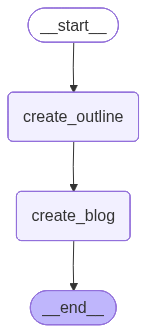

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [17]:
print(final_state['outline'])

Here's a detailed outline for a blog post on "The Rise of AI in India," designed to be comprehensive, engaging, and informative.

---

## Blog Title Options:

*   **The AI Awakening: How India is Embracing the Future**
*   **From Silicon Valley to Bengaluru: India's Ascent in the Global AI Landscape**
*   **India's AI Revolution: Opportunities, Challenges, and the Road Ahead**
*   **Decoding India's AI Boom: A Deep Dive into a Digital Transformation**

---

## Blog Outline: The Rise of AI in India

**Target Audience:** Tech enthusiasts, business leaders, policymakers, students, general public interested in India's digital transformation.

**Tone:** Informative, optimistic, balanced, forward-looking.

---

### I. Introduction (Approx. 150-200 words)

*   **A. Catchy Hook:**
    *   Start with a compelling statistic about India's digital growth or AI adoption.
    *   "Once known as the 'back office of the world,' India is rapidly transforming into a global AI powerhouse..."
    *   "The

In [18]:
print(final_state['content'])

## India's AI Revolution: Opportunities, Challenges, and the Road Ahead

The hum of innovation is growing louder in India, fueled by a technology that promises to redefine every aspect of life: Artificial Intelligence. Once known as the "back office of the world," India is rapidly transforming into a global AI powerhouse, leveraging its unique strengths to carve out a distinctive niche in the global AI landscape. The worldwide AI boom is undeniable, with its transformative potential impacting industries from healthcare to finance, and India is not just a spectator but a significant player in this unfolding drama.

With its vast talent pool, rapidly expanding digital infrastructure, and a myriad of unique challenges that AI can address, India presents fertile ground for groundbreaking innovation. This blog post will explore the multifaceted rise of AI in India, examining the key drivers, diverse applications, the burgeoning ecosystem, inherent challenges, and the exciting future that li